# Feature Analysis
Phân tích 4 feature ngôn ngữ để phân biệt Human vs AI text:
- **Burstiness**  độ bùng nổ từ vựng
- **Entropy**  độ hỗn loạn phân phối từ
- **TTR**  Type-Token Ratio, độ đa dạng từ vựng
- **Avg Sentence Length**  độ dài câu trung bình

In [7]:
!pip install matplotlib seaborn scipy -q

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from collections import Counter
import re

# Load data
df = pd.read_csv("/kaggle/input/datasets/minhbodoi/hoc-sau-20052026/processed_data/test.csv", encoding="utf-8-sig")
df["label_str"] = df["label"].map({0: "Human", 1: "AI"})
print(f"Test set: {len(df):,} records")
print(df.groupby(["language", "label_str"]).size().to_string())

Test set: 5,973 records
language  label_str
en        AI           1564
          Human        1075
vi        AI           1374
          Human        1960


In [9]:
#  Tính 4 features 

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def get_sentences(text):
    return [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

def calc_burstiness(text):
    """
    Burstiness = (std - mean) / (std + mean) của tần suất từ.
    AI text thường đều đặn hơn  burstiness thấp hơn human.
    """
    words = tokenize(text)
    if len(words) < 10:
        return np.nan
    freq = list(Counter(words).values())
    mu, sigma = np.mean(freq), np.std(freq)
    if mu + sigma == 0:
        return 0
    return (sigma - mu) / (sigma + mu)

def calc_entropy(text):
    """
    Shannon entropy của phân phối từ.
    AI text thường có entropy thấp hơn (phân phối đều hơn, ít bất ngờ hơn).
    """
    words = tokenize(text)
    if len(words) < 10:
        return np.nan
    freq = list(Counter(words).values())
    prob = np.array(freq) / sum(freq)
    return scipy_entropy(prob)

def calc_ttr(text):
    """
    Type-Token Ratio = unique words / total words.
    AI text thường lặp từ nhiều hơn  TTR thấp hơn.
    """
    words = tokenize(text)
    if len(words) == 0:
        return np.nan
    return len(set(words)) / len(words)

def calc_avg_sent_len(text):
    """
    Độ dài câu trung bình (số từ/câu).
    AI text thường có câu dài và đều hơn.
    """
    sentences = get_sentences(text)
    if len(sentences) == 0:
        return np.nan
    lengths = [len(tokenize(s)) for s in sentences]
    return np.mean(lengths)

print(" Đang tính features...")
df["burstiness"]    = df["text"].apply(calc_burstiness)
df["entropy"]       = df["text"].apply(calc_entropy)
df["ttr"]           = df["text"].apply(calc_ttr)
df["avg_sent_len"]  = df["text"].apply(calc_avg_sent_len)
print(" Xong!")
print(df[["burstiness", "entropy", "ttr", "avg_sent_len"]].describe().round(3).to_string())

 Đang tính features...
 Xong!
       burstiness   entropy       ttr  avg_sent_len
count    5972.000  5972.000  5973.000      5973.000
mean       -0.226     4.168     0.684        27.142
std         0.205     0.567     0.133        10.989
min        -1.000     2.405     0.224         1.667
25%        -0.335     3.747     0.602        20.778
50%        -0.186     4.396     0.667        24.875
75%        -0.077     4.602     0.766        33.000
max         0.294     5.509     1.000       175.000


/tmp/ipykernel_57/3099624739.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_str", y=feat,
/tmp/ipykernel_57/3099624739.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_str", y=feat,
/tmp/ipykernel_57/3099624739.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="label_str", y=feat,
/tmp/ipykernel_57/3099624739.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

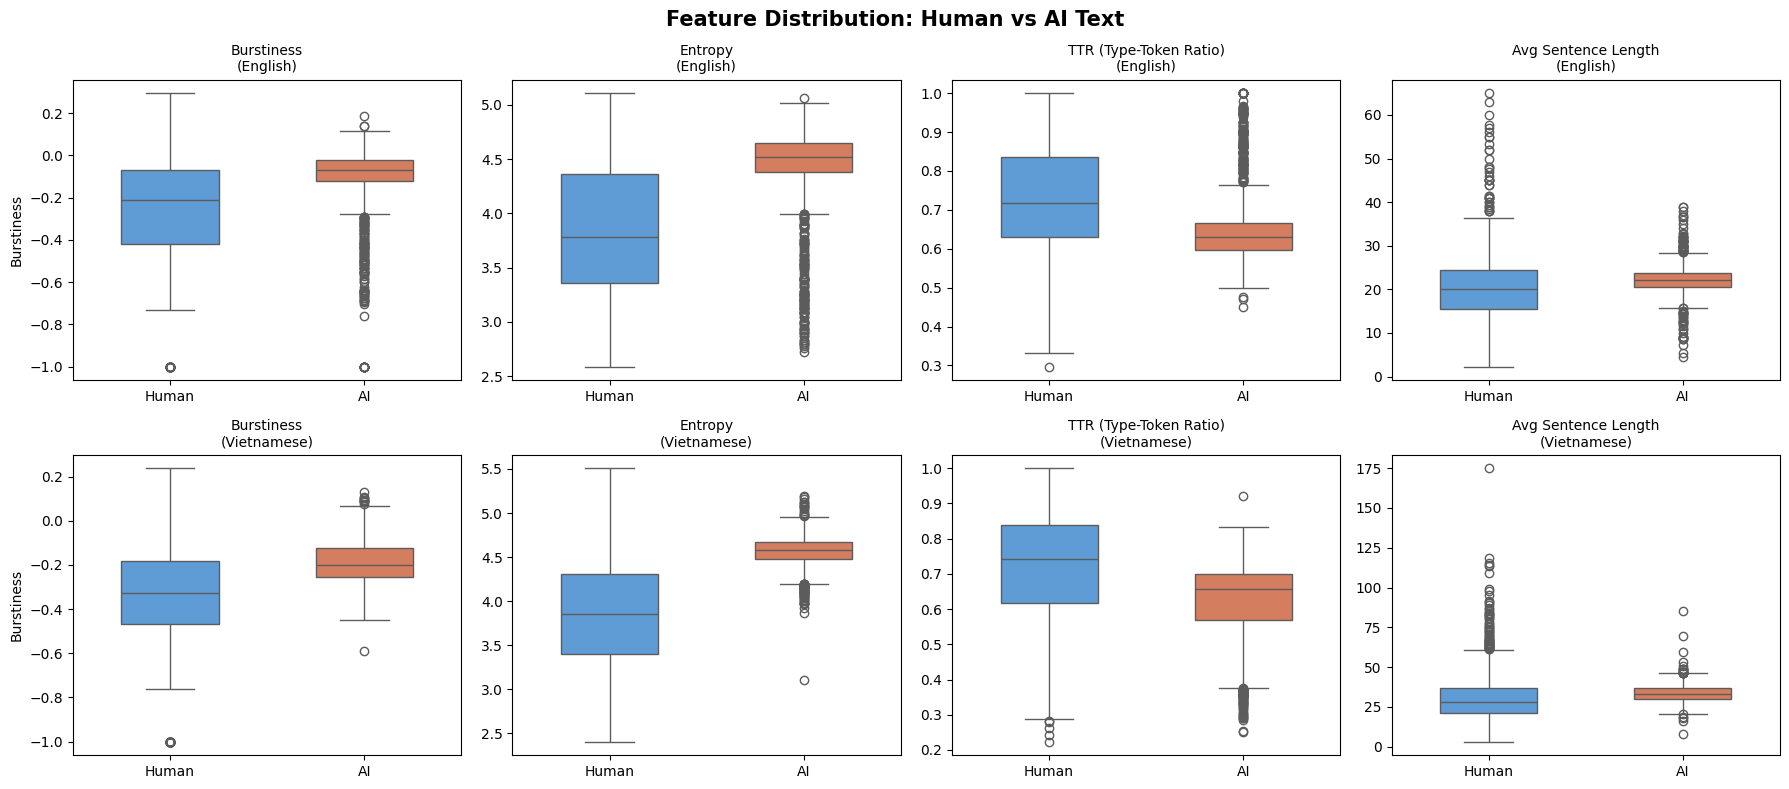

 Đã lưu: feature_analysis.png


In [10]:
#  Visualize: Boxplot 4 features × 2 ngôn ngữ 
FEATURES = {
    "burstiness":   "Burstiness",
    "entropy":      "Entropy",
    "ttr":          "TTR (Type-Token Ratio)",
    "avg_sent_len": "Avg Sentence Length",
}
LANGS    = {"en": "English", "vi": "Vietnamese"}
PALETTE  = {"Human": "#4C9BE8", "AI": "#E8734C"}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Feature Distribution: Human vs AI Text", fontsize=15, fontweight="bold")

for row, (lang, lang_name) in enumerate(LANGS.items()):
    sub = df[df["language"] == lang].dropna()
    for col, (feat, feat_name) in enumerate(FEATURES.items()):
        ax = axes[row][col]
        sns.boxplot(data=sub, x="label_str", y=feat,
                    palette=PALETTE, ax=ax, width=0.5,
                    order=["Human", "AI"])
        ax.set_title(f"{feat_name}\n({lang_name})", fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel(feat_name if col == 0 else "")

plt.tight_layout()
plt.savefig("feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Đã lưu: feature_analysis.png")

In [11]:
#  Thống kê trung bình theo nhóm 
print(" Trung bình các feature theo ngôn ngữ và nhãn:")
summary = df.groupby(["language", "label_str"])[["burstiness", "entropy", "ttr", "avg_sent_len"]].mean().round(4)
print(summary.to_string())

# Nhận xét tự động
print("\n Nhận xét:")
for lang in ["en", "vi"]:
    sub = df[df["language"] == lang]
    for feat in ["burstiness", "entropy", "ttr", "avg_sent_len"]:
        human_mean = sub[sub["label"] == 0][feat].mean()
        ai_mean    = sub[sub["label"] == 1][feat].mean()
        direction  = "cao hơn" if human_mean > ai_mean else "thấp hơn"
        diff_pct   = abs(human_mean - ai_mean) / (abs(ai_mean) + 1e-9) * 100
        print(f"  [{lang.upper()}] Human {feat} {direction} AI ({diff_pct:.1f}%)")

 Trung bình các feature theo ngôn ngữ và nhãn:
                    burstiness  entropy     ttr  avg_sent_len
language label_str                                           
en       AI            -0.1026   4.4306  0.6479       22.2232
         Human         -0.2544   3.8271  0.7325       20.1885
vi       AI            -0.1876   4.5597  0.6219       33.6112
         Human         -0.3358   3.8693  0.7287       30.3458

 Nhận xét:
  [EN] Human burstiness thấp hơn AI (148.0%)
  [EN] Human entropy thấp hơn AI (13.6%)
  [EN] Human ttr cao hơn AI (13.1%)
  [EN] Human avg_sent_len thấp hơn AI (9.2%)
  [VI] Human burstiness thấp hơn AI (79.0%)
  [VI] Human entropy thấp hơn AI (15.1%)
  [VI] Human ttr cao hơn AI (17.2%)
  [VI] Human avg_sent_len thấp hơn AI (9.7%)
